### Library

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
import multiprocessing as mp
if mp.get_start_method(allow_none=True) is None:
    mp.set_start_method('spawn')

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*input_shape.*')
warnings.filterwarnings('ignore', message='.*structure of.*inputs.*')

import os, time, gc
from types import SimpleNamespace

import numpy as np
import pandas as pd
import time as time_module
from scipy.stats import t
from scipy.special import kv, gamma

import jax, jax.numpy as jnp

import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder

import optuna
import plotly.io as pio

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

2026-02-10 11:37:37.907727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770694657.923417  194036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770694657.927937  194036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770694657.940403  194036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770694657.940427  194036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770694657.940428  194036 computation_placer.cc:177] computation placer alr

### Environment setting

In [3]:
np_f32 = np.float32
jnp_f32 = jnp.float32
dtype_basis = np.float32

jax.config.update("jax_enable_x64", False)

pio.renderers.default = "notebook"
warnings.filterwarnings("ignore", category=UserWarning)

os.environ.update({"TF_CPP_MIN_LOG_LEVEL": "2"})
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.environ.setdefault("OMP_NUM_THREADS", "12")
os.environ.setdefault("MKL_NUM_THREADS", "12")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "12")

def init_hardware(dtype: str = "float32"):
    gpus = tf.config.list_physical_devices("GPU")
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    strategy = (tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy())
    mixed_precision.set_global_policy(dtype)
    return strategy

strategy = init_hardware(dtype="float32")

### Auto save notebook

In [4]:
from IPython.display import display, Javascript

def save_notebook():
    display(Javascript('IPython.notebook.save_checkpoint()'))
    current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
    print(f"💾 Notebook saved at {current_time}")

### Our function

In [5]:
from spherical_deepkriging.basis_functions.wendland.wenland import wendland
from spherical_deepkriging.basis_functions.mrts.mrts import mrts0

from spherical_deepkriging.models.deep_kriging import DeepKrigingTrainer, DeepKrigingDefaultTrainer
from spherical_deepkriging.configs import DeepKrigingModelConfig, DeepKrigingDefaultConfig
from spherical_deepkriging.models.universal_kriging import UniversalKriging

from rpy2.robjects.conversion import localconverter
from spherical_deepkriging.basis_functions.mrts_sphere.sphere import mrts_sphere, numpy2ri_converter

R callback write-console: Registered S3 methods overwritten by 'RcppEigen':
  method               from         
  predict.fastLm       RcppArmadillo
  print.fastLm         RcppArmadillo
  summary.fastLm       RcppArmadillo
  print.summary.fastLm RcppArmadillo
  


### Simulation Helper

In [6]:
def simulate_data(num_sample, seed):
    """
    Experiment I : Stationary Gaussian processes + Eggholder Mean Function.
    """
    rng = np.random.default_rng(seed)
    
    # Generate spherical coordinates uniformly
    phi = rng.uniform(0, 2 * np.pi, num_sample)
    theta = np.arccos(rng.uniform(-1, 1, num_sample))
    lat_rad = np.pi/2 - theta
    lon_rad = phi - np.pi
    
    lat_deg = np.rad2deg(lat_rad).astype(np.float32)
    lon_deg = np.rad2deg(lon_rad).astype(np.float32)
    
    # Convert to Cartesian coordinates for distance calculation
    x_cart = np.cos(lat_rad) * np.cos(lon_rad)
    y_cart = np.cos(lat_rad) * np.sin(lon_rad)
    z_cart = np.sin(lat_rad)

    # Eggholder Mean Term
    x = 12.0 * x_cart
    y = 12.0 * y_cart
    
    term1 = -(y + 47.0) * np.sin(np.sqrt(np.abs(x + y/2.0 + 47.0)))
    term2 = -x * np.sin(np.sqrt(np.abs(x - (y + 47.0))))
    mean_term = (term1 + term2).astype(np.float32)
    
    coords = np.column_stack([x_cart, y_cart, z_cart]).astype(np.float32)
    
    # Covariance matrix with exponential covariance function
    dist_matrix = np.arccos(np.clip(coords @ coords.T, -1.0, 1.0))
    cov_matrix = np.exp(-dist_matrix / 0.5).astype(np.float32)
    
    # Add jitter for numerical stability
    jitter = 1e-3
    cov_matrix += np.float32(jitter) * np.eye(num_sample, dtype=np.float32)
    
    # Cholesky decomposition with error handling
    try:
        L = np.linalg.cholesky(cov_matrix)
    except np.linalg.LinAlgError:
        cov_matrix += np.float32(1e-2) * np.eye(num_sample, dtype=np.float32)
        try:
            L = np.linalg.cholesky(cov_matrix)
        except np.linalg.LinAlgError:
            eigenvals, eigenvecs = np.linalg.eigh(cov_matrix)
            eigenvals = np.maximum(eigenvals, 1e-6)
            L = eigenvecs @ np.diag(np.sqrt(eigenvals))
    
    # Generate Gaussian process: y = mean + L @ z
    z_std = rng.standard_normal(num_sample).astype(np.float32)
    y = mean_term + (L @ z_std).astype(np.float32)
    
    z = y
    
    print(f"\nSimulate Data | z mean: {np.mean(y):.4f} ({np.std(y) / np.sqrt(num_sample):.4f}), Variance: {np.var(y, ddof=0):.4f}, Range: [{np.min(y):.4f}, {np.max(y):.4f}]")
    
    del phi, theta, lat_rad, lon_rad, x_cart, y_cart, z_cart, coords, dist_matrix, cov_matrix, L, z_std
    gc.collect()
    
    return pd.DataFrame({
        "longitude": lon_deg,
        "latitude": lat_deg,
        "z": z,
    })

### Helper

In [7]:
def data_preprocessing(data_frame):
    data = data_frame.copy()

    numeric_cols = ["longitude", "latitude", "z"]
    data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors="coerce")
    data.dropna(subset=numeric_cols, inplace=True)

    lon, lat = data["longitude"].to_numpy(), data["latitude"].to_numpy()

    norm_lon = (lon - lon.min()) / (lon.max() - lon.min())
    norm_lat = (lat - lat.min()) / (lat.max() - lat.min())

    location_data = np.column_stack([lat, lon]).astype("float32")
    location_data_norm = np.column_stack([norm_lon, norm_lat]).astype("float32")
    y_combined = data['z'].to_numpy().astype("float32")[:, None]

    # Handle
    categorical_data = None

    return location_data, location_data_norm, categorical_data, y_combined


def precompute_wendland(location, num_basis):
    parts = []
    for nb in num_basis:
        grid = np.column_stack(np.meshgrid(
            np.linspace(0, 1, int(np.sqrt(nb)), dtype=np_f32),
            np.linspace(0, 1, int(np.sqrt(nb)), dtype=np_f32),
        )).reshape(-1, 2).astype(np_f32)

        theta = np_f32(2.5)/np_f32(np.sqrt(nb))
        parts.append(
            wendland(location, grid, theta=theta, k=2)
        )

        # Clean up the memory
        del grid
        gc.collect()

    return np.hstack(parts).astype(dtype_basis, copy=False)


def precompute_max_mrts(distance_type, location_data, knot_num, order_max, knot=None):
    if knot is None:
        idx_knot = np.random.choice(location_data.shape[0], knot_num, replace=False)
        knot = location_data[idx_knot].astype(np_f32)
    else:
        idx_knot = None

    if distance_type == "sphere":
        with localconverter(numpy2ri_converter):
            res_r = mrts_sphere(knot, order_max, location_data.astype(np_f32))
        res_dict = dict(zip(res_r.names(), res_r))
        phi = np.asarray(res_dict["mrts"], dtype=dtype_basis)
    else:
        phi = np.asarray(
            mrts0(jnp.asarray(knot, dtype=jnp_f32), k=order_max, 
                  x=jnp.asarray(location_data, dtype=jnp_f32)), dtype=dtype_basis
        )

    return phi, idx_knot, knot


def prepare_data(categorical_data, basis, y_combined, seed, split_ratio=(0.8, 0.1, 0.1)):
    idx_all = np.arange(basis.shape[0])
    train_ratio, val_ratio, test_ratio = split_ratio
    
    train_val_x1, test_x1 = train_test_split(
        idx_all, train_size=train_ratio+val_ratio, random_state=seed)
    train_x1, val_x1 = train_test_split(
        train_val_x1, train_size=train_ratio/(train_ratio+val_ratio), random_state=seed)
    
    X_train_cont, X_val_cont, X_test_cont = (
        basis[train_x1], basis[val_x1], basis[test_x1])
    y_train, y_val, y_test = (
        y_combined[train_x1], y_combined[val_x1], y_combined[test_x1])
    
    def flatten(targets):
        return targets.reshape(-1).astype(np_f32, copy=False)
    y_train_flat, y_val_flat, y_test_flat = map(flatten, [y_train, y_val, y_test])

    def flatten(covariates):
        return covariates.reshape(-1, basis.shape[1]).astype(np_f32)
    X_train_cont_flat, X_val_cont_flat, X_test_cont_flat = map(flatten, [X_train_cont, X_val_cont, X_test_cont])
    
    # Handle categorical features
    if categorical_data is None:
        zero_vector = lambda n: np.zeros((n, 0), dtype=np_f32)
        X_train_cat, X_val_cat, X_test_cat = map(zero_vector, [len(X_train_cont_flat), len(X_val_cont_flat), len(X_test_cont_flat)])
    else:
        cat_train = categorical_data.reshape(-1, 1)[train_x1]
        cat_val = categorical_data.reshape(-1, 1)[val_x1]
        cat_test = categorical_data.reshape(-1, 1)[test_x1]
        
        OHE = OneHotEncoder(sparse_output=False, dtype=np_f32)
        X_train_cat = OHE.fit_transform(cat_train).astype(np_f32)
        X_val_cat = OHE.transform(cat_val).astype(np_f32)
        X_test_cat = OHE.transform(cat_test).astype(np_f32)
    
    return (X_train_cont_flat, X_train_cat, y_train_flat,
            X_val_cont_flat, X_val_cat, y_val_flat,
            X_test_cont_flat, X_test_cat, y_test_flat)


def train_eval(name_model, epochs, batch_size, loss, dropout_rate,
               X_train, X_train_cat, y_train,
               X_val, X_val_cat, y_val,
               X_test, X_test_cat, y_test):

    if name_model in ["OLS_wendland", "OLS_sphere"]:
        t0 = time.time()
        model = LinearRegression().fit(X_train, y_train)
            
        val_loss = float(mean_squared_error(y_val, model.predict(X_val)))
        y_pred = model.predict(X_test).astype(np_f32).reshape(-1)
        training_time = time.time() - t0
        
        metrics = {
            "Model": name_model,
            "Val_loss": float(val_loss),
            "MSPE": float(mean_squared_error(y_test, y_pred)),
            "RMSE": float(np.sqrt(float(mean_squared_error(y_test, y_pred)))),
            "MAE": float(mean_absolute_error(y_test, y_pred)),
            "R2": float(r2_score(y_test, y_pred)),
            "Time": float(training_time),
        }
        
        return metrics, model
    
    elif name_model == "DeepKriging_wendland":
        config = DeepKrigingDefaultConfig(
            input_dim=X_train.shape[1],
            output_type='continuous',
            optimizer=Adam(learning_rate=1e-3),
            loss=loss,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

    elif name_model == "DeepKriging_wendland*":
        optimizer = Adam(learning_rate=5e-3)
        config = DeepKrigingModelConfig(
            input_dim=X_train.shape[1],
            output_type='continuous',
            hidden_layers=[1024, 512, 256, 128, 64],
            activation='relu',
            dropout_rate=dropout_rate,
            optimizer=optimizer,
            loss=loss,
            metrics=['mae'],
            epochs=epochs,
            batch_size=batch_size,
            patience=40,
            verbose=0
        )

    elif name_model in ["DeepKriging_mrts", "DeepKriging_sphere", "DeepKriging_sphere_Huber"]:
        optimizer = Adam(learning_rate=5e-3)
        config = DeepKrigingModelConfig(
            input_dim=X_train.shape[1],
            output_type='continuous',
            hidden_layers=[1024, 512, 256, 128, 64],
            activation='relu',
            dropout_rate=dropout_rate,
            optimizer=optimizer,
            loss=loss,
            metrics=['mae'],
            epochs=epochs,
            batch_size=batch_size,
            patience=40,
            verbose=0
        )

    t0 = time.time()
    with strategy.scope():
        if name_model == "DeepKriging_wendland":
            model = DeepKrigingDefaultTrainer(config)
        elif name_model == "DeepKriging_wendland*":
            model = DeepKrigingTrainer(config)
        else:
            model = DeepKrigingTrainer(config)
        model.model.compile(optimizer=config.optimizer, loss=config.loss, metrics=config.metrics)

    checkpoint_path = f"best_{name_model}_{time.time_ns()}.weights.h5"
    if name_model == "DeepKriging_wendland":
        callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_path, monitor="val_loss", mode="min",
                save_best_only=True, save_weights_only=True, verbose=0)
        ]
    else:
        callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_path, monitor="val_loss", mode="min",
                save_best_only=True, save_weights_only=True, verbose=0),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=config.patience, restore_best_weights=True, verbose=0),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=max(5, config.patience // 2), min_lr=1e-6, verbose=0)
        ]

    train_dataset = tf.data.Dataset.from_tensor_slices((
        (X_train, X_train_cat), y_train
    )).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)

    val_dataset = tf.data.Dataset.from_tensor_slices((
        (X_val, X_val_cat), y_val
    )).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)

    history = model.model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )

    if os.path.exists(checkpoint_path):
        model.model.load_weights(checkpoint_path)
        os.remove(checkpoint_path)
    
    val_loss = float(np.min(history.history["val_loss"]))
    y_pred = model.model.predict([X_test, X_test_cat], verbose=0).reshape(-1).astype(np_f32)
    training_time = time.time() - t0

    metrics = {
        "Model": name_model,
        "Val_loss": float(val_loss),
        "MSPE": float(mean_squared_error(y_test, y_pred)),
        "RMSE": float(np.sqrt(float(mean_squared_error(y_test, y_pred)))),
        "MAE": float(mean_absolute_error(y_test, y_pred)),
        "R2": float(r2_score(y_test, y_pred)),
        "Time": float(training_time),
    }
    
    del train_dataset, val_dataset
    gc.collect()
    
    return metrics, model


def cleanup_tf_session():
    K.clear_session()
    gc.collect()
    try:
        tf.keras.backend.clear_session()
    except:
        pass

In [8]:
def plot_robinson(ax, longitude, latitude, value, vmin, vmax, title):
    """Plot data on Robinson projection"""
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, alpha=0.5)

    sc = ax.scatter(longitude, latitude, c=value, 
                    cmap=mcolors.LinearSegmentedColormap.from_list("teal-yellow-red", ["#00AAAA", "#FFFFBB", "#FF3333"], N=256), 
                    s=10, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

    ax.set_title(title, fontsize=10, pad=3)
    return sc


def create_subplot_robinson(fig, position, locations, values, vmin, vmax, title, plot_type='prediction', cbar_label=None):
    """Create subplot with Robinson projection"""
    ax = fig.add_subplot(*position, projection=ccrs.Robinson())
    
    # Choose colormap based on plot type
    if plot_type == 'residual':
        cmap = mcolors.LinearSegmentedColormap.from_list("blue-white-red", ["#2166AC", "#F7F7F7", "#B2182B"], N=256)
    else:
        cmap = mcolors.LinearSegmentedColormap.from_list("teal-yellow-red", ["#00AAAA", "#FFFFBB", "#FF3333"], N=256)
    
    # Set global view
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, alpha=0.5)
    
    # Plot scatter
    sc = ax.scatter(locations['longitude'], locations['latitude'], c=values, 
                    cmap=cmap, s=10, transform=ccrs.PlateCarree(), 
                    vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=10, pad=3)
    
    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04, shrink=0.8)
    
    if cbar_label is None:
        cbar_label = "Residual" if plot_type == 'residual' else "Prediction Value"
    
    # Increased fontsize to match old version
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=7)
    
    return ax, sc


def visualize_comparison(dataframe, models_dict, basis_dict, y_combined, seed, model_list=None, experiment_info=None):
    """Visualize model predictions and residuals using Robinson projection"""
    if model_list is None:
        model_list = ['DeepKriging_sphere', 'DeepKriging_sphere_Huber', 'UniversalKriging']
    
    idx_all = np.arange(len(y_combined))
    train_val_idx, test_idx = train_test_split(idx_all, train_size=0.9, random_state=seed)
    y_test = y_combined[test_idx].reshape(-1)
    test_locations = dataframe.iloc[test_idx]
    
    predictions = {}
    for model_name in model_list:
        if model_name not in models_dict or models_dict[model_name] is None:
            continue
        
        model = models_dict[model_name]
        X_test = basis_dict[model_name][test_idx]
        
        if "DeepKriging" in model_name:
            X_test_cat = np.zeros((len(X_test), 0), dtype=np.float32)
            y_pred = model.model.predict([X_test, X_test_cat], verbose=0).reshape(-1)
        elif model_name == "UniversalKriging":
            coords_test = dataframe[['longitude', 'latitude']].iloc[test_idx].values.astype(np.float32)
            y_pred = model.predict(coords_test, X_test, return_centered=False)
        else:
            y_pred = model.predict(X_test).reshape(-1)
        
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        order = models_dict.get(f"{model_name}_order", "")
        
        predictions[model_name] = {
            'values': y_pred,
            'rmse': rmse,
            'order': order
        }
    
    # Calculate global min/max for consistent color scale
    all_values = [dataframe['z'].values] + [p['values'] for p in predictions.values()]
    all_values_concat = np.concatenate(all_values)
    vmin = np.percentile(all_values_concat, 2)
    vmax = np.percentile(all_values_concat, 98)
    
    # Figure 1: Predictions comparison
    fig1 = plt.figure(figsize=(16, 14))
    
    noise_info = ""
    if experiment_info:
        noise_info = f"Noise={experiment_info.get('noise', 'None')}"
        if experiment_info.get('noise_var'):
            noise_info += f", Var={experiment_info['noise_var']}"
    
    # Plot real data
    create_subplot_robinson(
        fig1, (2, 2, 1), dataframe, dataframe['z'], vmin, vmax,
        f'Real Data (n={len(dataframe)})',
        plot_type='prediction'
    )
    
    # Plot predictions
    subplot_positions = [(2, 2, 2), (2, 2, 3), (2, 2, 4)]
    for i, model_name in enumerate(model_list):
        if model_name in predictions:
            pred = predictions[model_name]
            display_name = model_name.replace('DeepKriging_sphere', 'DK_S').replace('_Huber', '_H').replace('UniversalKriging', 'UK')
            
            create_subplot_robinson(
                fig1, subplot_positions[i], test_locations, pred['values'], vmin, vmax,
                f"{display_name} (order={pred['order']}) | Test n={len(test_idx)} | RMSE={pred['rmse']:.4f}",
                plot_type='prediction'
            )
    
    # Modified title fontsize and layout to match old version
    plt.suptitle(
        "Prediction Comparison: Real Data vs. Models Predict\n"
        f"Stationary Gaussian processes + Eggholder (without noise and outliers)",
        fontsize=20, fontweight='bold', y=0.84
    )
    # Reverted to tight_layout with rect, as in the old version
    plt.tight_layout(rect=[0, 0.02, 1, 0.94])
    plt.show()
    plt.close(fig1)
    

    # Figure 2: Residuals comparison
    fig2 = plt.figure(figsize=(18, 6))
    
    residuals_map = {k: (y_test - predictions[k]['values']) 
                     for k in model_list if k in predictions}
    vmax_abs = max(np.max(np.abs(r)) for r in residuals_map.values())
    
    for i, model_name in enumerate(model_list):
        if model_name in predictions:
            residuals = residuals_map[model_name]
            display_name = model_name.replace('DeepKriging_sphere', 'DK_S').replace('_Huber', '_H').replace('UniversalKriging', 'UK')
            
            create_subplot_robinson(
                fig2, (1, 3, i+1), test_locations, residuals, -vmax_abs, vmax_abs,
                f"{display_name} Residuals (order={predictions[model_name]['order']})",
                plot_type='residual'
            )
    
    # Modified title fontsize and layout to match old version
    plt.suptitle(
        f"Residuals Comparison | Stationary Gaussian processes + Eggholder (without noise and outliers)",
        fontsize=20, fontweight='bold', y=0.84
    )
    # Reverted to tight_layout with rect
    plt.tight_layout(rect=[0, 0.02, 1, 0.94])
    plt.show()
    plt.close(fig2)
    
    return predictions, test_idx

### Experiment Setup

In [9]:
# Model Setup
seed = 1
epochs = 500
batch_size = 256
num_sample = 2500
huber_delta = 1.345

# Basis Setup
num_basis = [10**2, 19**2, 37**2]
knot_num = 1400
order_max = 1400

base_orders = [50, 100, 200, 500, 700, 1000, 1400]

# Repeat 
repeat_experiment = 10


🏃 Repeat 1/10, Seed=1

Simulate Data | z mean: -19.6440 (0.5117), Variance: 654.6295, Range: [-63.4451, 31.6165]


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.



Tuning order parameter for OLS_sphere
   Order      Val Loss     Test MSE    
   ----------------------------------
   50         0.3058       0.2476      
   100        0.2204       0.1855      
   200        0.1567       0.1166      
   500        0.1234       0.0946       *
   700        0.1302       0.1456      
   1000       0.2766       0.1993      
   1400       2.6666       60.9620     
   Best order: 500

Tuning order parameter for DeepKriging_mrts


I0000 00:00:1770694684.421742  194036 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17712 MB memory:  -> device: 0, name: NVIDIA RTX 4000 Ada Generation, pci bus id: 0000:70:00.0, compute capability: 8.9
I0000 00:00:1770694686.785327 1355052 service.cc:152] XLA service 0x58759803b770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770694686.785388 1355052 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 4000 Ada Generation, Compute Capability 8.9
I0000 00:00:1770694687.172326 1355052 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1770694689.726507 1355052 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   Order      Val Loss     Test MSE    
   ----------------------------------
   50         1.6895       1.4211      
   100        1.0954       0.8381       *
   200        1.4799       1.6814      
   500        3.7373       4.4274      
   700        2.6935       2.5509      
   1000       1.3269       1.7319      
   1400       3.0752       3.7770      
   Best order: 100

Tuning order parameter for DeepKriging_sphere
   Order      Val Loss     Test MSE    
   ----------------------------------
   50         133.3905     122.0624    
   100        146.1122     145.6155    
   200        0.8925       0.9559      
   500        0.8789       0.9643       *
   700        16.9419      29.9878     
   1000       97.4112      101.0457    
   1400       370.1122     344.7411    
   Best order: 500

Tuning order parameter for DeepKriging_sphere_Huber
   Order      Val Loss     Test MSE    
   ----------------------------------
   50         0.0875       0.1536      
   100        0.0745    

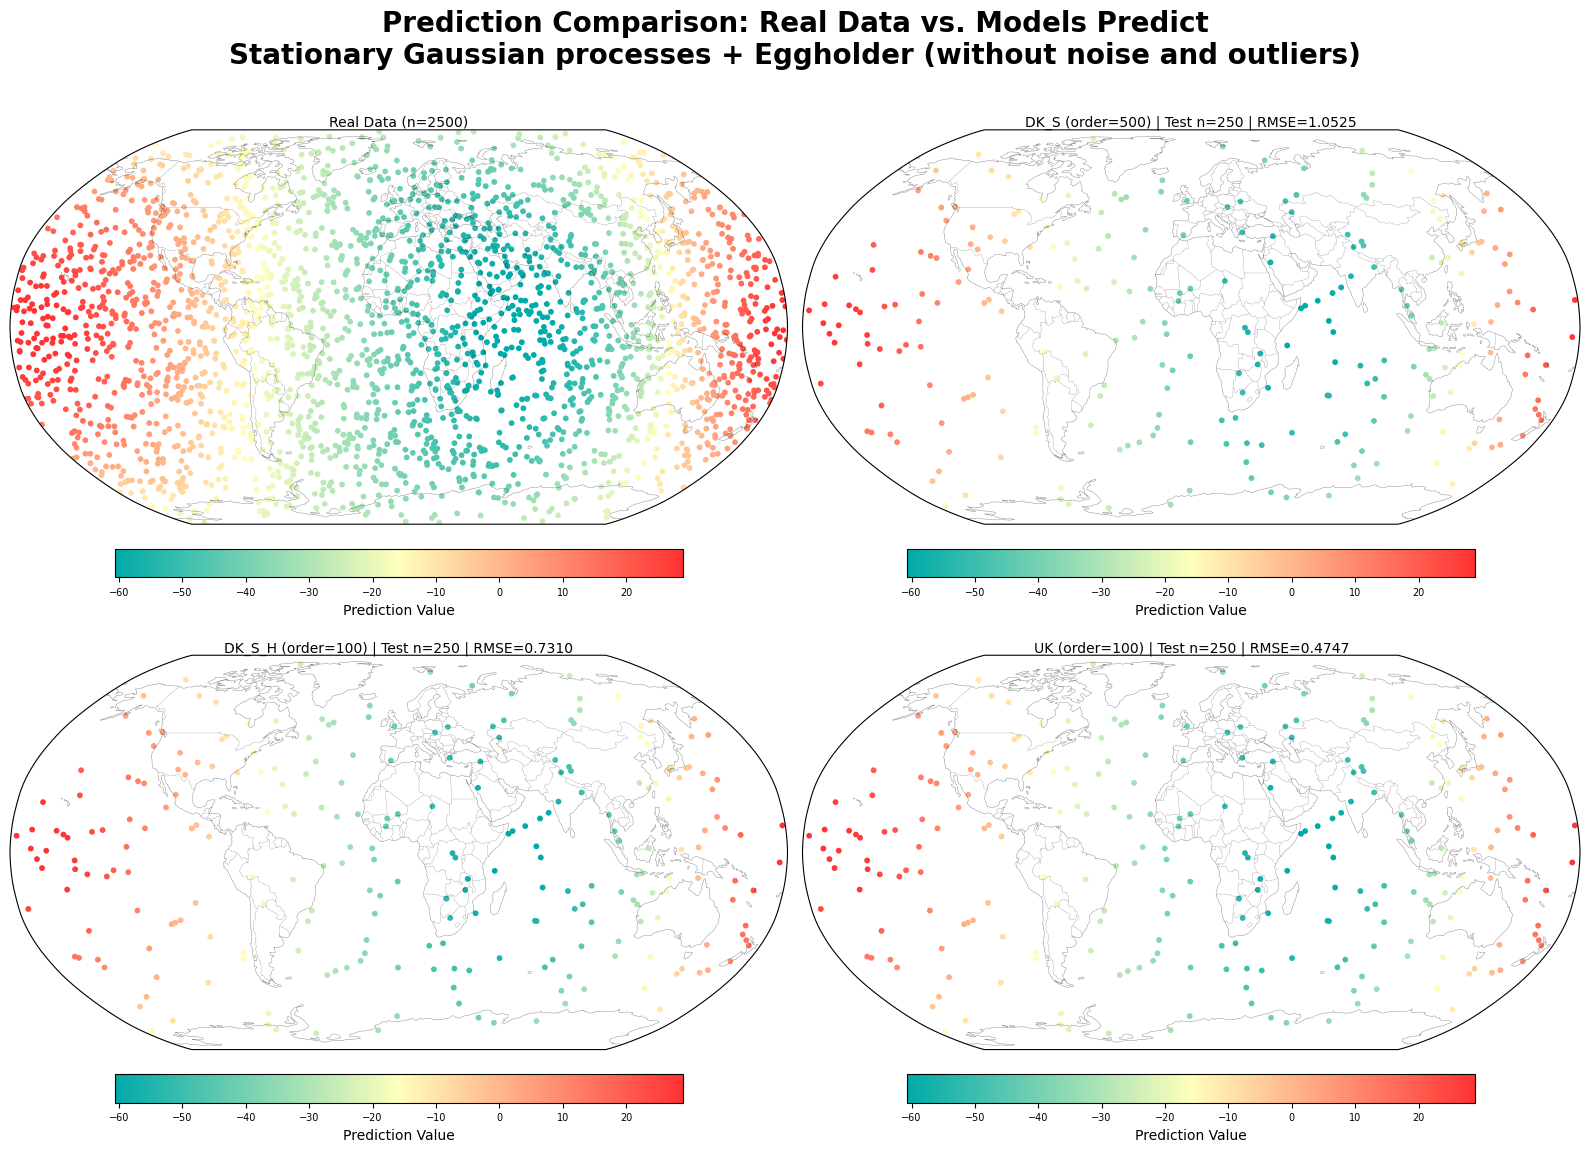

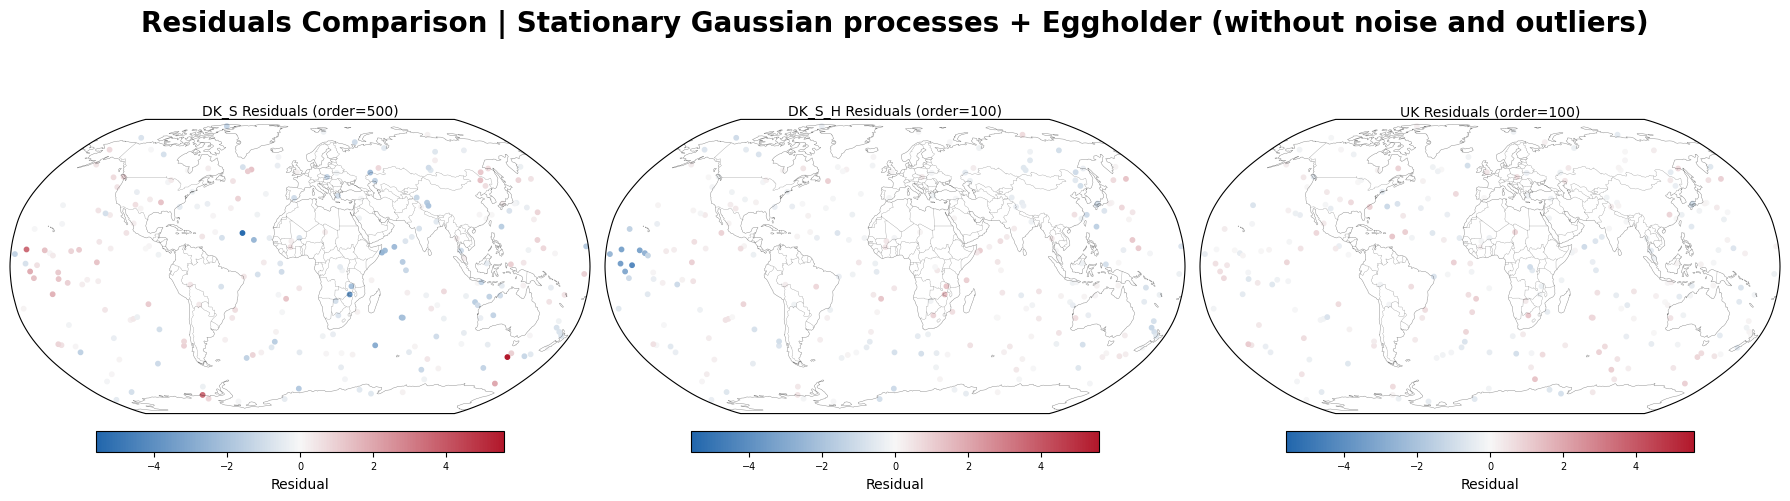

<IPython.core.display.Javascript object>

💾 Notebook saved at 2026-02-10 11:52:45

✅ Completed Repeat 1/10

🏃 Repeat 2/10, Seed=2

Simulate Data | z mean: -19.0863 (0.5074), Variance: 643.6517, Range: [-60.9934, 31.4891]
Covariance function: exponential (Matérn ν=0.5)
Fitted parameters: nu=0.5000, rho=0.0905, sigma²=0.1900, nugget=0.0011

| Model                    | Param   |      MSPE |    RMSE |     MAE |      R2 | Time   |
|--------------------------|---------|-----------|---------|---------|---------|--------|
| OLS_wendland             | --      | 3576.55   | 59.8042 | 20.0339 | -4.5992 | 0.44s  |
| OLS_sphere               | 500     |    0.1255 |  0.3543 |  0.2729 |  0.9998 | 0.07s  |
| DeepKriging_wendland     | --      |  285.6    | 16.8997 | 11.5218 |  0.5529 | 46.38s |
| DeepKriging_wendland*    | --      |  281.228  | 16.7698 | 11.597  |  0.5597 | 20.05s |
| DeepKriging_mrts         | 100     |    9.1242 |  3.0206 |  2.499  |  0.9857 | 20.38s |
| DeepKriging_sphere       | 500     |    7.7573 |  2.7852 |  1.072  | 

<IPython.core.display.Javascript object>

💾 Notebook saved at 2026-02-10 11:55:56

✅ Completed Repeat 2/10

🏃 Repeat 3/10, Seed=4

Simulate Data | z mean: -19.8603 (0.5059), Variance: 639.7552, Range: [-62.0271, 31.0718]
Covariance function: exponential (Matérn ν=0.5)
Fitted parameters: nu=0.5000, rho=0.1000, sigma²=0.2120, nugget=0.0000

| Model                    | Param   |     MSPE |    RMSE |     MAE |     R2 | Time   |
|--------------------------|---------|----------|---------|---------|--------|--------|
| OLS_wendland             | --      | 491.58   | 22.1716 | 16.1497 | 0.2654 | 0.40s  |
| OLS_sphere               | 500     |   0.1039 |  0.3224 |  0.2525 | 0.9998 | 0.06s  |
| DeepKriging_wendland     | --      | 258.238  | 16.0698 | 10.5962 | 0.6141 | 46.65s |
| DeepKriging_wendland*    | --      | 251.02   | 15.8436 |  9.7644 | 0.6249 | 31.49s |
| DeepKriging_mrts         | 100     |   0.2475 |  0.4975 |  0.3943 | 0.9996 | 57.81s |
| DeepKriging_sphere       | 500     |   1.3729 |  1.1717 |  0.7295 | 0.9979 | 45.80s

<IPython.core.display.Javascript object>

...

💾 Notebook saved at 2026-02-10 12:22:03

✅ Completed Repeat 8/10

🏃 Repeat 9/10, Seed=37

Simulate Data | z mean: -19.7190 (0.5125), Variance: 656.5314, Range: [-60.4699, 31.3241]
Covariance function: exponential (Matérn ν=0.5)
Fitted parameters: nu=0.5000, rho=0.0831, sigma²=0.1887, nugget=0.0006

| Model                    | Param   |     MSPE |    RMSE |     MAE |     R2 | Time   |
|--------------------------|---------|----------|---------|---------|--------|--------|
| OLS_wendland             | --      | 381.896  | 19.5422 | 14.9299 | 0.4087 | 0.38s  |
| OLS_sphere               | 500     |   0.1243 |  0.3525 |  0.2755 | 0.9998 | 0.06s  |
| DeepKriging_wendland     | --      | 264.683  | 16.2691 | 10.7545 | 0.5902 | 75.97s |
| DeepKriging_wendland*    | --      | 254.147  | 15.942  | 10.4183 | 0.6065 | 27.23s |
| DeepKriging_mrts         | 100     |   6.0644 |  2.4626 |  1.8715 | 0.9906 | 28.27s |
| DeepKriging_sphere       | 500     |  10.7598 |  3.2802 |  1.2177 | 0.9833 | 69.22

<IPython.core.display.Javascript object>

💾 Notebook saved at 2026-02-10 12:27:05

✅ Completed Repeat 9/10

🏃 Repeat 10/10, Seed=46

Simulate Data | z mean: -18.3749 (0.5066), Variance: 641.6500, Range: [-61.1502, 31.7570]
Covariance function: exponential (Matérn ν=0.5)
Fitted parameters: nu=0.5000, rho=0.0876, sigma²=0.1827, nugget=0.0000

| Model                    | Param   |     MSPE |    RMSE |     MAE |     R2 | Time   |
|--------------------------|---------|----------|---------|---------|--------|--------|
| OLS_wendland             | --      | 342.792  | 18.5146 | 14.3709 | 0.4134 | 0.46s  |
| OLS_sphere               | 500     |   0.1292 |  0.3595 |  0.286  | 0.9998 | 0.07s  |
| DeepKriging_wendland     | --      | 206.859  | 14.3826 |  9.5092 | 0.646  | 76.83s |
| DeepKriging_wendland*    | --      | 189.553  | 13.7678 |  9.0296 | 0.6756 | 29.06s |
| DeepKriging_mrts         | 100     |   7.8908 |  2.8091 |  2.1935 | 0.9865 | 30.22s |
| DeepKriging_sphere       | 500     |   1.2666 |  1.1254 |  0.7599 | 0.9978 | 69.9

<IPython.core.display.Javascript object>

💾 Notebook saved at 2026-02-10 12:32:25

✅ Completed Repeat 10/10


In [10]:
best_orders = {}

experiment_results = {
    model: {"MSPE": [], "RMSE": [], "MAE": [], "R2": []}
    for model in ["OLS_wendland", "OLS_sphere", "DeepKriging_wendland", "DeepKriging_wendland*", "DeepKriging_mrts", "DeepKriging_sphere", "DeepKriging_sphere_Huber", "UniversalKriging"]
}


for repeat in range(repeat_experiment):
    seed = seed + repeat

    print(f"\n{'='*80}")
    print(f"🏃 Repeat {repeat+1}/{repeat_experiment}, Seed={seed}")
    print(f"{'='*80}")

    dataframe = simulate_data(num_sample=num_sample, seed=seed)
    location_data, location_data_norm, categorical_data, y_combined = data_preprocessing(dataframe)

    # Compute max MRTS_Sphere, MRTS_Euclidean
    max_Phi_sphere, idx_knot, knot = precompute_max_mrts("sphere", location_data, knot_num, order_max, knot=None)
    max_Phi_sphere = max_Phi_sphere.astype(dtype_basis, copy=False)

    max_Phi_mrts, idx_knot_mrts, knot_mrts = precompute_max_mrts("mrts", location_data, knot_num, order_max, knot=location_data[idx_knot])
    max_Phi_mrts = max_Phi_mrts.astype(dtype_basis, copy=False)

    # Compute Wendland basis
    Phi_wendland = precompute_wendland(location_data_norm, num_basis)


    if repeat == 0:
        # Tuning order parameter for OLS_sphere
        Best_val_OLS_S = float('inf')
        Best_order_OLS_S = None
        Results_order_OLS_S = []
        
        print("\nTuning order parameter for OLS_sphere")
        for order in base_orders:
            Phi_sphere = max_Phi_sphere[:, :order].astype(np_f32)
            parts = prepare_data(categorical_data, Phi_sphere, y_combined, seed)
            metrics, model = train_eval(
                "OLS_sphere", None, None, None, None, *parts
            )
            
            Results_order_OLS_S.append({'order': order, 'val_loss': metrics["Val_loss"], 'mspe': metrics["MSPE"]})
            
            if metrics["Val_loss"] < Best_val_OLS_S:
                Best_val_OLS_S = metrics["Val_loss"]
                Best_order_OLS_S = order
            
            del Phi_sphere, parts, model
            gc.collect()

        # Print results table
        print(f"   {'Order':<10} {'Val Loss':<12} {'Test MSE':<12}")
        print(f"   {'-'*34}")
        for res in Results_order_OLS_S:
            marker = " *" if res['order'] == Best_order_OLS_S else ""
            print(f"   {res['order']:<10} {res['val_loss']:<12.4f} {res['mspe']:<12.4f}{marker}")
        print(f"   Best order: {Best_order_OLS_S}")
        best_orders['OLS_sphere'] = Best_order_OLS_S


        # Tuning order parameter for DeepKriging_mrts
        Best_val_DK_mrts = float('inf')
        Best_order_DK_mrts = None
        Results_order_DK_mrts = []

        print("\nTuning order parameter for DeepKriging_mrts")
        for order in base_orders:
            Phi_mrts = max_Phi_mrts[:, :order].astype(np_f32)
            parts = prepare_data(categorical_data, Phi_mrts, y_combined, seed)
            with strategy.scope():
                metrics, model = train_eval(
                    "DeepKriging_mrts", epochs, batch_size, "mse", 0.01, *parts
                )
            
            # Store results
            Results_order_DK_mrts.append({'order': order, 'val_loss': metrics["Val_loss"], 'mspe': metrics["MSPE"]})
            
            if metrics["Val_loss"] < Best_val_DK_mrts:
                Best_val_DK_mrts = metrics["Val_loss"]
                Best_order_DK_mrts = order
            
            del Phi_mrts, parts
            cleanup_tf_session()

        # Print results table
        print(f"   {'Order':<10} {'Val Loss':<12} {'Test MSE':<12}")
        print(f"   {'-'*34}")
        for res in Results_order_DK_mrts:
            marker = " *" if res['order'] == Best_order_DK_mrts else ""
            print(f"   {res['order']:<10} {res['val_loss']:<12.4f} {res['mspe']:<12.4f}{marker}")
        print(f"   Best order: {Best_order_DK_mrts}")
        best_orders['DeepKriging_mrts'] = Best_order_DK_mrts


        # Tuning order parameter for DeepKriging_sphere
        Best_val_DK_S = float('inf')
        Best_order_DK_S = None
        Results_order_DK_S = []

        print("\nTuning order parameter for DeepKriging_sphere")
        for order in base_orders:
            Phi_sphere = max_Phi_sphere[:, :order].astype(np_f32)
            parts = prepare_data(categorical_data, Phi_sphere, y_combined, seed)
            with strategy.scope():
                metrics, model = train_eval(
                    "DeepKriging_sphere", epochs, batch_size, "mse", 0.01, *parts
                )
            
            # Store results
            Results_order_DK_S.append({'order': order, 'val_loss': metrics["Val_loss"], 'mspe': metrics["MSPE"]})
            
            if metrics["Val_loss"] < Best_val_DK_S:
                Best_val_DK_S = metrics["Val_loss"]
                Best_order_DK_S = order
            
            del Phi_sphere, parts
            cleanup_tf_session()

        # Print results table
        print(f"   {'Order':<10} {'Val Loss':<12} {'Test MSE':<12}")
        print(f"   {'-'*34}")
        for res in Results_order_DK_S:
            marker = " *" if res['order'] == Best_order_DK_S else ""
            print(f"   {res['order']:<10} {res['val_loss']:<12.4f} {res['mspe']:<12.4f}{marker}")
        print(f"   Best order: {Best_order_DK_S}")
        best_orders['DeepKriging_sphere'] = Best_order_DK_S


        # Tuning order parameter for DeepKriging_sphere_Huber
        Best_val_DK_S_H = float('inf')
        Best_order_DK_S_H = None
        Results_order_DK_S_H = []
        
        print("\nTuning order parameter for DeepKriging_sphere_Huber")
        for order in base_orders:
            Phi_sphere = max_Phi_sphere[:, :order].astype(np_f32)
            parts = prepare_data(categorical_data, Phi_sphere, y_combined, seed)
            with strategy.scope():
                metrics, model = train_eval(
                    "DeepKriging_sphere_Huber", epochs, batch_size, Huber(delta=huber_delta), 0.01, *parts
                )
            
            # Store results
            Results_order_DK_S_H.append({'order': order, 'val_loss': metrics["Val_loss"], 'mspe': metrics["MSPE"]})
            
            if metrics["Val_loss"] < Best_val_DK_S_H:
                Best_val_DK_S_H = metrics["Val_loss"]
                Best_order_DK_S_H = order
            
            del Phi_sphere, parts
            cleanup_tf_session()

        # Print results table
        print(f"   {'Order':<10} {'Val Loss':<12} {'Test MSE':<12}")
        print(f"   {'-'*34}")
        for res in Results_order_DK_S_H:
            marker = " *" if res['order'] == Best_order_DK_S_H else ""
            print(f"   {res['order']:<10} {res['val_loss']:<12.4f} {res['mspe']:<12.4f}{marker}")
        print(f"   Best order: {Best_order_DK_S_H}")
        best_orders['DeepKriging_sphere_Huber'] = Best_order_DK_S_H


        # Tuning order parameter for UniversalKriging
        Best_val_UK = float('inf')
        Best_order_UK = None
        Results_order_UK = []
        
        print("\nTuning order parameter for UniversalKriging")
        for order in base_orders:
            Phi_sphere = max_Phi_sphere[:, :order].astype(np_f32)
            
            idx_all = np.arange(Phi_sphere.shape[0])
            train_val_idx, test_idx = train_test_split(idx_all, train_size=0.9, random_state=seed)
            train_idx, val_idx = train_test_split(train_val_idx, train_size=8/9, random_state=seed)
            
            # Prepare coordinates, basis and y
            coords_train, coords_val, coords_test = location_data[train_idx], location_data[val_idx], location_data[test_idx]
            phi_train, phi_val, phi_test = Phi_sphere[train_idx], Phi_sphere[val_idx], Phi_sphere[test_idx]
            y_train, y_val, y_test = y_combined[train_idx].flatten(), y_combined[val_idx].flatten(), y_combined[test_idx].flatten()
            
            # Train UniversalKriging
            uk_model = UniversalKriging(num_neighbors=30, cov_function='exponential')
            uk_model.fit(coords_train, phi_train, y_train, center_y=True)
            
            # Predict on validation set
            y_pred_val = uk_model.predict(coords_val, phi_val, return_centered=True)
            val_loss = mean_squared_error(y_val - uk_model.y_mean, y_pred_val)
            
            # Predict on test set
            y_pred_test = uk_model.predict(coords_test, phi_test, return_centered=False)
            test_mse = mean_squared_error(y_test, y_pred_test)
            
            # Store results
            Results_order_UK.append({'order': order, 'val_loss': val_loss, 'mspe': test_mse})
            
            if val_loss < Best_val_UK:
                Best_val_UK = val_loss
                Best_order_UK = order
            
            # Cleanup
            uk_model.cleanup()
            del uk_model, Phi_sphere, coords_train, coords_val, coords_test
            del phi_train, phi_val, phi_test, y_train, y_val, y_test
            gc.collect()
                
        # Print results table
        print(f"   {'Order':<10} {'Val Loss':<12} {'Test MSE':<12}")
        print(f"   {'-'*34}")
        for res in Results_order_UK:
            marker = " *" if res['order'] == Best_order_UK else ""
            print(f"   {res['order']:<10} {res['val_loss']:<12.4f} {res['mspe']:<12.4f}{marker}")
        print(f"   Best order: {Best_order_UK}")
        best_orders['UniversalKriging'] = Best_order_UK
        gc.collect()


    # Repeat experiment
    Record = {}

    # OLS_wendland
    parts = prepare_data(categorical_data, Phi_wendland, y_combined, seed)
    metric, model = train_eval(
        "OLS_wendland", None, None, None, None, *parts
    )
    Record["OLS_wendland"] = {
        "MSPE": metric["MSPE"], "RMSE": metric["RMSE"], "MAE": metric["MAE"], "R2": metric["R2"],
        "Time": metric["Time"], "Param": "--", "model": model if repeat == 0 else None
    }

    if repeat != 0:
        del model
    del parts
    gc.collect()


    # OLS_sphere
    Phi_sphere = max_Phi_sphere[:, :best_orders['OLS_sphere']].astype(np_f32)
    parts = prepare_data(categorical_data, Phi_sphere, y_combined, seed)
    metric, model = train_eval(
        "OLS_sphere", None, None, None, None, *parts
    )
    Record["OLS_sphere"] = {
        "MSPE": metric["MSPE"], "RMSE": metric["RMSE"], "MAE": metric["MAE"], "R2": metric["R2"],
        "Time": metric["Time"], "Param": best_orders['OLS_sphere'], "model": model if repeat == 0 else None
    }
    if repeat != 0:
        del model
    del Phi_sphere, parts
    gc.collect()


    # DeepKriging_wendland
    parts = prepare_data(categorical_data, Phi_wendland, y_combined, seed)
    with strategy.scope():
        metric, model = train_eval(
            "DeepKriging_wendland", epochs, batch_size, "mse", 0.5, *parts
        )
    Record["DeepKriging_wendland"] = {
        "MSPE": metric["MSPE"], "RMSE": metric["RMSE"], "MAE": metric["MAE"], "R2": metric["R2"],
        "Time": metric["Time"], "Param": "--", "model": model if repeat == 0 else None
    }

    if repeat != 0:
        del model
        cleanup_tf_session()
    del parts
    gc.collect()


    # DeepKriging_wendland*
    parts = prepare_data(categorical_data, Phi_wendland, y_combined, seed)
    with strategy.scope():
        metric, model = train_eval(
            "DeepKriging_wendland*", epochs, batch_size, "mse", 0.01, *parts
        )
    Record["DeepKriging_wendland*"] = {
        "MSPE": metric["MSPE"], "RMSE": metric["RMSE"], "MAE": metric["MAE"], "R2": metric["R2"],
        "Time": metric["Time"], "Param": "--", "model": model if repeat == 0 else None
    }

    if repeat != 0:
        del model
        cleanup_tf_session()
    del parts
    gc.collect()


    # DeepKriging_mrts
    Phi_mrts = max_Phi_mrts[:, :best_orders['DeepKriging_mrts']].astype(np_f32)
    parts = prepare_data(categorical_data, Phi_mrts, y_combined, seed)
    with strategy.scope():
        metric, model = train_eval(
            "DeepKriging_mrts", epochs, batch_size, "mse", 0.01, *parts
        )
    Record["DeepKriging_mrts"] = {
        "MSPE": metric["MSPE"], "RMSE": metric["RMSE"], "MAE": metric["MAE"], "R2": metric["R2"],
        "Time": metric["Time"], "Param": best_orders['DeepKriging_mrts'], "model": model if repeat == 0 else None
    }
    if repeat != 0:
        del model
        cleanup_tf_session()
    del Phi_mrts, parts
    gc.collect()


    # DeepKriging_sphere
    Phi_sphere = max_Phi_sphere[:, :best_orders['DeepKriging_sphere']].astype(np_f32)
    parts = prepare_data(categorical_data, Phi_sphere, y_combined, seed)
    with strategy.scope():
        metric, model = train_eval(
            "DeepKriging_sphere", epochs, batch_size, "mse", 0.01, *parts
        )
    Record["DeepKriging_sphere"] = {
        "MSPE": metric["MSPE"], "RMSE": metric["RMSE"], "MAE": metric["MAE"], "R2": metric["R2"],
        "Time": metric["Time"], "Param": best_orders['DeepKriging_sphere'], "model": model if repeat == 0 else None
    }
    if repeat != 0:
        del model
        cleanup_tf_session()
    del Phi_sphere, parts
    gc.collect()


    # DeepKriging_sphere_Huber
    Phi_sphere = max_Phi_sphere[:, :best_orders['DeepKriging_sphere_Huber']].astype(np_f32)
    parts = prepare_data(categorical_data, Phi_sphere, y_combined, seed)
    with strategy.scope():
        metric, model = train_eval(
            "DeepKriging_sphere_Huber", epochs, batch_size, Huber(delta=huber_delta), 0.01, *parts
        )
    Record["DeepKriging_sphere_Huber"] = {
        "MSPE": metric["MSPE"], "RMSE": metric["RMSE"], "MAE": metric["MAE"], "R2": metric["R2"],
        "Time": metric["Time"], "Param": best_orders['DeepKriging_sphere_Huber'], "model": model if repeat == 0 else None
    }
    if repeat != 0:
        del model
        cleanup_tf_session()
    del Phi_sphere, parts
    gc.collect()


    # UniversalKriging
    t0 = time.time()
    Phi_sphere = max_Phi_sphere[:, :best_orders['UniversalKriging']].astype(np_f32)
    
    idx_all = np.arange(Phi_sphere.shape[0])
    train_val_idx, test_idx = train_test_split(idx_all, train_size=0.9, random_state=seed)
    train_idx, _ = train_test_split(train_val_idx, train_size=8/9, random_state=seed)

    # Prepare train/test data
    coords_train, coords_test = location_data[train_idx], location_data[test_idx]
    phi_train, phi_test = Phi_sphere[train_idx], Phi_sphere[test_idx]
    y_train, y_test = y_combined[train_idx].flatten(), y_combined[test_idx].flatten()

    # Train model
    uk_model = UniversalKriging(num_neighbors=30, cov_function='exponential')
    uk_model.fit(coords_train, phi_train, y_train, center_y=True)

    y_pred_test = uk_model.predict(coords_test, phi_test, return_centered=False)

    Record["UniversalKriging"] = {
        "MSPE": mean_squared_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "R2": r2_score(y_test, y_pred_test),
        "Time": time.time() - t0,
        "Param": best_orders['UniversalKriging'],
        "model": uk_model if repeat == 0 else None
    }

    # Cleanup
    if repeat != 0:
        uk_model.cleanup()
        del uk_model
    del Phi_sphere, coords_train, coords_test, phi_train, phi_test, y_train, y_test
    gc.collect()


    # Model performance comparison
    result_table = []
    for model in ["OLS_wendland", "OLS_sphere", "DeepKriging_wendland", "DeepKriging_wendland*", "DeepKriging_mrts", "DeepKriging_sphere", "DeepKriging_sphere_Huber", "UniversalKriging"]:
        result_table.append({
            "Model": model, "Param": Record[model]["Param"],
            "MSPE": f"{Record[model]['MSPE']:.4f}", "RMSE": f"{Record[model]['RMSE']:.4f}", "MAE": f"{Record[model]['MAE']:.4f}", "R2": f"{Record[model]['R2']:.4f}",
            "Time": f"{Record[model]['Time']:.2f}s"
        })

    df_res = pd.DataFrame(result_table)
    print("\n", df_res.to_markdown(index=False, tablefmt="github"), sep="")

    # Visualized model predict and residual
    if repeat == 0:
        experiment_info = {'noise': 'None', 'noise_var': None}
    
        visualized_model = {
            "DeepKriging_sphere": Record["DeepKriging_sphere"]["model"],
            "DeepKriging_sphere_order": Record["DeepKriging_sphere"]["Param"],
            "DeepKriging_sphere_Huber": Record["DeepKriging_sphere_Huber"]["model"],
            "DeepKriging_sphere_Huber_order": Record["DeepKriging_sphere_Huber"]["Param"],
            "UniversalKriging": Record["UniversalKriging"]["model"],
            "UniversalKriging_order": Record["UniversalKriging"]["Param"]
        }
        
        visualized_basis = {
            "DeepKriging_sphere": max_Phi_sphere[:, :best_orders['DeepKriging_sphere']],
            "DeepKriging_sphere_Huber": max_Phi_sphere[:, :best_orders['DeepKriging_sphere_Huber']],
            "UniversalKriging": max_Phi_sphere[:, :best_orders['UniversalKriging']]
        }
        
        predictions, test_idx = visualize_comparison(
            dataframe, visualized_model, visualized_basis, y_combined, seed,
            model_list=['DeepKriging_sphere', 'DeepKriging_sphere_Huber', 'UniversalKriging'],
            experiment_info=experiment_info
        )
        cleanup_tf_session()

    # Save all results
    for model in ["OLS_wendland", "OLS_sphere", "DeepKriging_wendland", "DeepKriging_wendland*", "DeepKriging_mrts", "DeepKriging_sphere", "DeepKriging_sphere_Huber", "UniversalKriging"]:
        experiment_results[model]["MSPE"].append(Record[model]["MSPE"])
        experiment_results[model]["RMSE"].append(Record[model]["RMSE"])
        experiment_results[model]["MAE"].append(Record[model]["MAE"])
        experiment_results[model]["R2"].append(Record[model]["R2"])

    # Clean up
    del Phi_wendland, max_Phi_sphere, dataframe, location_data, location_data_norm
    cleanup_tf_session()
    gc.collect()

    save_notebook()
    print(f"\n✅ Completed Repeat {repeat+1}/{repeat_experiment}")

### Summary of All Experiments

In [11]:
print("\n" + "="*80)
print("📊 Summary of repeat experiments")
print("="*80)
print(f"Selected Best Orders: {best_orders}")
print("="*80)

avg_results = []
for model in ["OLS_wendland", "OLS_sphere", "DeepKriging_wendland", "DeepKriging_wendland*", "DeepKriging_mrts", "DeepKriging_sphere", "DeepKriging_sphere_Huber", "UniversalKriging"]:
    metrics = experiment_results[model]
    
    avg_results.append({
        "Model": model,
        "MSPE": f"{np.mean(metrics['MSPE']):.2f}±{np.std(metrics['MSPE']):.2f}",
        "RMSE": f"{np.mean(metrics['RMSE']):.2f}±{np.std(metrics['RMSE']):.2f}",
        "MAE": f"{np.mean(metrics['MAE']):.2f}±{np.std(metrics['MAE']):.2f}",
        "R2": f"{np.mean(metrics['R2']):.2f}±{np.std(metrics['R2']):.2f}",
    })

df_avg = pd.DataFrame(avg_results)
print("\n", df_avg.to_markdown(index=False, tablefmt="github"), sep="")

if avg_results:
    best_model = min(avg_results, key=lambda x: float(x["RMSE"].split("±")[0]))
    print(f"\n🏆 Best Model: {best_model['Model']} (RMSE: {best_model['RMSE']})")


📊 Summary of repeat experiments
Selected Best Orders: {'OLS_sphere': 500, 'DeepKriging_mrts': 100, 'DeepKriging_sphere': 500, 'DeepKriging_sphere_Huber': 100, 'UniversalKriging': 100}

| Model                    | MSPE          | RMSE        | MAE        | R2         |
|--------------------------|---------------|-------------|------------|------------|
| OLS_wendland             | 784.48±935.41 | 25.47±11.64 | 16.20±1.54 | -0.23±1.46 |
| OLS_sphere               | 0.12±0.01     | 0.35±0.02   | 0.28±0.02  | 1.00±0.00  |
| DeepKriging_wendland     | 253.78±33.73  | 15.89±1.08  | 10.47±0.74 | 0.60±0.04  |
| DeepKriging_wendland*    | 246.34±39.98  | 15.64±1.31  | 10.13±1.24 | 0.61±0.05  |
| DeepKriging_mrts         | 3.34±3.26     | 1.57±0.94   | 1.24±0.74  | 0.99±0.01  |
| DeepKriging_sphere       | 13.55±29.02   | 2.66±2.55   | 1.60±1.97  | 0.98±0.05  |
| DeepKriging_sphere_Huber | 0.23±0.11     | 0.47±0.10   | 0.37±0.05  | 1.00±0.00  |
| UniversalKriging         | 0.10±0.01     | 0.31